Проектная работа. Группа 10. KNN-2. Хуснутдинов Эдуард Ринатович. Нуман Ахмед. Эспиноза Ортис Хуан Карлос

Метод KNN для классификации достаточно простой, поэтому давайте применим наши знания для создания пайплайна и применения GridSearchCV - их можно будет использовать и для других моделей.


# Water quality

## О наборе данных
### Контекст
Это набор данных, созданный на основе вымышленных данных о качестве воды в городской среде. Я рекомендую использовать этот набор данных в образовательных целях, для практики и для приобретения необходимых знаний.

### Содержание
Внутри находятся не только строки и столбцы. Вы можете увидеть ингредиенты для воды, указанные в качестве названий столбцов.

### Описание
Все атрибуты являются числовыми переменными и перечислены ниже:

алюминий — опасен, если его концентрация превышает 2,8.
Аммиак – опасен, если его концентрация превышает 32,5.
мышьяк — опасен, если его концентрация превышает 0,01.
барий – опасен, если его концентрация превышает 2.
кадмий — опасен, если его концентрация превышает 0,005.
хлорамин — опасен, если его концентрация превышает 4.
Хром — опасен, если его концентрация превышает 0,1.
медь – опасно, если ее концентрация превышает 1,3.
Фтор — опасен, если его концентрация превышает 1,5.
бактерии - опасны, если их количество превышает 0
вирусы - опасны, если их количество превышает 0
Свинец – опасен, если его концентрация превышает 0,015.
нитраты — опасны, если их концентрация превышает 10.
нитриты — опасны, если их концентрация превышает 1.
ртуть – опасна, если ее концентрация превышает 0,002.
перхлорат - опасен, если его концентрация превышает 56.
Радий — опасен, если его концентрация превышает 5.
селен — опасен, если его концентрация превышает 0,5.
серебро — опасно, если его концентрация превышает 0,1.
уран — опасен, если его концентрация превышает 0,3.
is_safe - атрибут класса {0 - небезопасно, 1 - безопасно}
### Вдохновение
Идея заключалась в создании набора данных, подходящего для бинарной классификации и дающего адекватные результаты.


Источник данных: https://www.kaggle.com/datasets/mssmartypants/water-quality

### Выполните задания, написанные жирным шрифтом

**ЗАДАНИЕ: Выполните ячейки ниже, чтобы загрузить данные.**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('waterQuality_cleaned.csv')

In [3]:
df.head()

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,target
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7996 entries, 0 to 7995
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7996 non-null   float64
 1   ammonia      7996 non-null   float64
 2   arsenic      7996 non-null   float64
 3   barium       7996 non-null   float64
 4   cadmium      7996 non-null   float64
 5   chloramine   7996 non-null   float64
 6   chromium     7996 non-null   float64
 7   copper       7996 non-null   float64
 8   flouride     7996 non-null   float64
 9   bacteria     7996 non-null   float64
 10  viruses      7996 non-null   float64
 11  lead         7996 non-null   float64
 12  nitrates     7996 non-null   float64
 13  nitrites     7996 non-null   float64
 14  mercury      7996 non-null   float64
 15  perchlorate  7996 non-null   float64
 16  radium       7996 non-null   float64
 17  selenium     7996 non-null   float64
 18  silver       7996 non-null   float64
 19  uranium      7996

In [5]:
df.describe()

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,target
count,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,...,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000
mean,0.666396,14.278212,0.161477,1.567928,0.042803,2.177589,0.247300,0.805940,0.771646,0.319714,...,0.099431,9.819250,1.329846,0.005193,16.465266,2.920106,0.049684,0.147811,0.044672,0.114057
std,1.265323,8.878930,0.252632,1.216227,0.036049,2.567210,0.270663,0.653595,0.435423,0.329497,...,0.058169,5.541977,0.573271,0.002967,17.688827,2.322805,0.028773,0.143569,0.026906,0.317900
min,0.000000,-0.080000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.040000,6.577500,0.030000,0.560000,0.008000,0.100000,0.050000,0.090000,0.407500,0.000000,...,0.048000,5.000000,1.000000,0.003000,2.170000,0.820000,0.020000,0.040000,0.020000,0.000000
50%,0.070000,14.130000,0.050000,1.190000,0.040000,0.530000,0.090000,0.750000,0.770000,0.220000,...,0.102000,9.930000,1.420000,0.005000,7.745000,2.410000,0.050000,0.080000,0.050000,0.000000
75%,0.280000,22.132500,0.100000,2.482500,0.070000,4.240000,0.440000,1.390000,1.160000,0.610000,...,0.151000,14.610000,1.760000,0.008000,29.487500,4.670000,0.070000,0.240000,0.070000,0.000000
max,5.050000,29.840000,1.050000,4.940000,0.130000,8.680000,0.900000,2.000000,1.500000,1.000000,...,0.200000,19.830000,2.930000,0.010000,60.010000,7.990000,0.100000,0.500000,0.090000,1.000000


In [6]:
df['target'].value_counts()

target
0    7084
1     912
Name: count, dtype: int64

## Исследование данных

**ЗАДАНИЕ: Нарисуйте тепловую карту heatmap, показывающую корреляцию между откликами на различных частотах.**

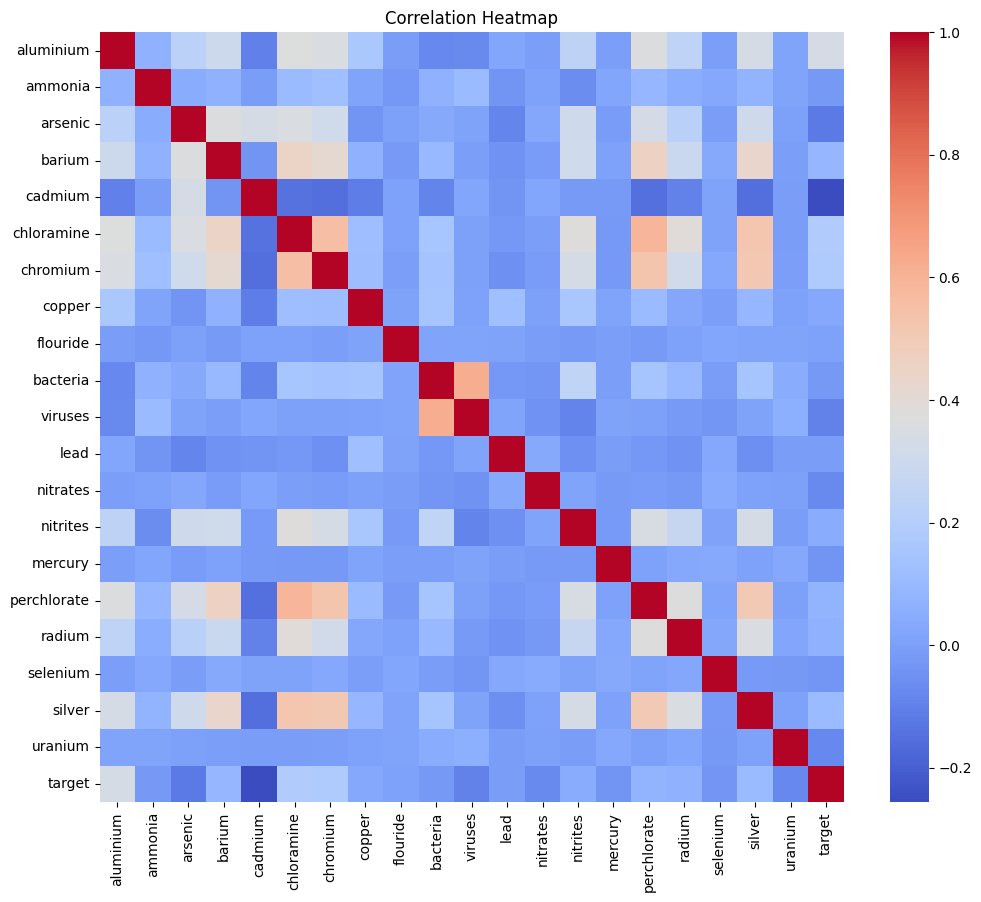

In [7]:
# Напишите Ваш код здесь
corr = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [8]:
target_corr = corr['target']
target_corr = target_corr.drop('target')
target_corr_abs = target_corr.abs()

In [9]:
top5 = target_corr_abs.sort_values(ascending=False).head(5)

print(top5)

aluminium     0.333974
cadmium       0.256034
chloramine    0.186704
chromium      0.182306
arsenic       0.123362
Name: target, dtype: float64


Для изучения взаимосвязей между переменными была построена тепловая карта (корреляционная тепловая карта).

Были рассчитаны коэффициенты корреляции между всеми признаками и целевой переменной, после чего были взяты их абсолютные значения для определения наиболее значимых факторов независимо от направления связи.
В результате было выявлено, что 5 наиболее коррелирующих признаков: aluminium, cadmium, chloramine, chromium, arsenic.

Это указывает на то, что данные химические элементы оказывают наибольшее влияние на определение безопасности воды.


In [10]:
# Напишите Ваш код здесь



## Разбиение на обучающий и тестовый наборы данных

Здесь мы будем использовать кросс-валидацию на 90% данных, и затем оценим результаты работы нашей модели на тестовом наборе данных в 10%.

**ЗАДАНИЕ: Разделите данные на признаки и целевую переменную, а затем разбейте все данные на обучающий и тестовый наборы данных, в отношении 90% и 10%.**

In [11]:
# Напишите Ваш код здесь
from sklearn.model_selection import train_test_split



In [12]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)


**ЗАДАНИЕ: Создайте объект PipeLine, в котором будет StandardScaler и модель KNN**

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [14]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

**ЗАДАНИЕ: С помощью пайплайна выполните поиск по сетке для различных значений k, и выведите наилучшие параметры.**

In [15]:
from sklearn.model_selection import GridSearchCV

In [16]:
param_grid = {
    'knn__n_neighbors': list(range(1, 21))
}

grid = GridSearchCV(pipeline, param_grid, cv=5)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate

In [17]:
print(grid.best_params_)

{'knn__n_neighbors': 11}


Для подбора оптимального значения параметра k в алгоритме KNN был использован метод Grid Search с кросс-валидацией.
Были протестированы различные значения k в диапазоне от 1 до 20 с использованием 5-кратной кросс-валидации.
k = 11

ЗАДАНИЕ: Используя словарь .cv_results_, попробуйте нарисовать график средних тестовых оценок (mean_test_score) для каждого значения K.**

In [18]:
# Напишите Ваш код здесь
import matplotlib.pyplot as plt

In [19]:
k_values = grid.cv_results_['param_knn__n_neighbors']
mean_scores = grid.cv_results_['mean_test_score']

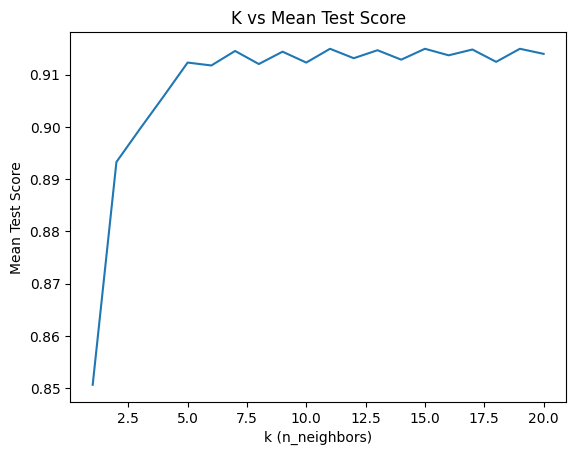

In [20]:
plt.figure()
plt.plot(k_values, mean_scores)
plt.xlabel("k (n_neighbors)")
plt.ylabel("Mean Test Score")
plt.title("K vs Mean Test Score")
plt.show()

### Финальная оценка модели

**ЗАДАНИЕ: используя объект grid classifier с предыдущего шага, создайте финальный отчёт "classification report" и матрицу "confusion matrix".**

In [21]:
# Напишите Ваш код здесь
from sklearn.metrics import classification_report, confusion_matrix

In [22]:
y_pred = grid.predict(X_test)

In [23]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95       698
           1       0.79      0.29      0.43       102

    accuracy                           0.90       800
   macro avg       0.85      0.64      0.69       800
weighted avg       0.89      0.90      0.88       800

[[690   8]
 [ 72  30]]


Модель была оценена на тестовой выборке, и точность (Accuracy) составила около 0.90, что на первый взгляд выглядит хорошо.

Класс 0 (небезопасная вода): Recall = 0.99 → модель отлично распознаёт

Класс 1 (безопасная вода): Recall = 0.29  → модель плохо определяет безопасные случаи

Матрица ошибок:
Модель в большинстве случаев предсказывает класс 0
Только 30 из 102 безопасных случаев распознаны правильно

Несмотря на высокую точность, модель показывает несбалансированное качество и плохо справляется с меньшим классом.

### Отличная работа!

==============
# Улучшение модели
==============

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [25]:
pipeline_improved = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

In [26]:
from sklearn.model_selection import GridSearchCV

In [27]:
param_grid_improved = {
    'knn__n_neighbors': list(range(1, 21))
}

grid_improved = GridSearchCV(
    pipeline_improved,
    param_grid_improved,
    cv=5,
    scoring='f1'
)

grid_improved.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate

In [28]:
print(grid_improved.best_params_)

{'knn__n_neighbors': 5}


In [29]:
from sklearn.metrics import classification_report, confusion_matrix

In [30]:
y_pred_improved = grid_improved.predict(X_test)

print(classification_report(y_test, y_pred_improved))
print(confusion_matrix(y_test, y_pred_improved))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       698
           1       0.68      0.33      0.45       102

    accuracy                           0.90       800
   macro avg       0.79      0.66      0.69       800
weighted avg       0.88      0.90      0.88       800

[[682  16]
 [ 68  34]]


In [31]:

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)


param_grid_best = {
    'knn__n_neighbors': list(range(1, 31)),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

grid_best = GridSearchCV(
    pipeline_improved,
    param_grid_best,
    cv=5,
    scoring='f1_macro'
)

grid_best.fit(X_train_s, y_train_s)

print(grid_best.best_params_)

{'knn__n_neighbors': 9, 'knn__p': 2, 'knn__weights': 'uniform'}


In [32]:
y_pred_best = grid_best.predict(X_test_s)

print(classification_report(y_test_s, y_pred_best))
print(confusion_matrix(y_test_s, y_pred_best))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       709
           1       0.84      0.42      0.56        91

    accuracy                           0.93       800
   macro avg       0.89      0.70      0.76       800
weighted avg       0.92      0.93      0.91       800

[[702   7]
 [ 53  38]]


In [33]:
top_features = ['aluminium', 'cadmium', 'chloramine', 'chromium', 'arsenic']

In [34]:
X_top = df[top_features]
y_top = df['target']

In [35]:
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_top, y_top, test_size=0.1, random_state=42, stratify=y_top
)

In [36]:
grid_top = GridSearchCV(
    pipeline_improved,
    param_grid_best,
    cv=5,
    scoring='f1_macro'
)

grid_top.fit(X_train_t, y_train_t)

print(grid_top.best_params_)

{'knn__n_neighbors': 15, 'knn__p': 2, 'knn__weights': 'distance'}


In [37]:
y_pred_top = grid_top.predict(X_test_t)

print(classification_report(y_test_t, y_pred_top))
print(confusion_matrix(y_test_t, y_pred_top))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       709
           1       0.62      0.49      0.55        91

    accuracy                           0.91       800
   macro avg       0.78      0.73      0.75       800
weighted avg       0.90      0.91      0.90       800

[[682  27]
 [ 46  45]]


Был проведён дополнительный эксперимент с использованием только 5 наиболее значимых признаков с целью уменьшения размерности данных и фокусировки на наиболее важных факторах.

Результаты показали заметное улучшение в распознавании меньшего класса (безопасная вода): значение Recall увеличилось с 0.42 до 0.49, что является наилучшим результатом среди всех экспериментов.

Однако общая точность модели снизилась с 0.93 до 0.91 из-за увеличения количества ошибок для другого класса.